# 03 · Modelado — MVP del Sistema de Recomendación
### ShopSmart Recommender — Entrenamiento y comparación de modelos

**Objetivo de este notebook**

Entrenar y comparar **dos modelos de recomendación** sobre los
artefactos generados en `02_feature_engineering.ipynb`, cumpliendo el
hito de la Etapa 1: *"un primer MVP del sistema de recomendación"*, con
foco en la **correcta aplicación de la metodología, la justificación de
decisiones y la capacidad de evaluación**, más que en la optimización
exhaustiva del desempeño.

**Los dos modelos del MVP**

| | Modelo A — Content-Based | Modelo B — Popularity (colaborativo-implícito) |
|---|---|---|
| Tipo | Personalizado por producto | No personalizado ("Top Picks") |
| Señal | Similitud coseno sobre features de contenido | Rating bayesiano + sentimiento + volumen de reseñas |
| Responde a | *"Si te gusta este producto, también te puede interesar..."* | *"Los productos mejor valorados del catálogo"* |
| Rol típico | Página de producto, "productos relacionados" | Home / landing, usuarios nuevos (cold start total) |

Como se documentó en el notebook 02, el dataset no tiene identificador
de usuario, por lo que **no existe un filtrado colaborativo clásico
como alternativa real** — comparar estos dos enfoques (personalizado
vs. no-personalizado) es la comparación más honesta y metodológicamente
correcta que se puede hacer con estos datos, y es además la comparación
estándar en la literatura de sistemas de recomendación para justificar
cuándo vale la pena personalizar.

**Metodología de evaluación**

Sin historial de usuario no es posible calcular *precision/recall*
contra interacciones reales. Se usan en su lugar **métricas proxy
defendibles**, estándar para evaluar sistemas basados en contenido sin
*ground truth* explícito: coherencia de categoría, cobertura de
catálogo, diversidad intra-lista y calidad promedio de lo recomendado.
El detalle y la justificación de cada métrica están en la sección 4.

## 0. Configuración del entorno

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.evaluation import (  # noqa: E402
    avg_recommendation_quality,
    catalog_coverage_at_k,
    category_precision_at_k,
    intra_list_diversity,
)
from src.models.recommenders import ContentBasedRecommender, PopularityRecommender  # noqa: E402

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"


def save_fig(fig, name: str) -> None:
    """Guarda una figura en `reports/figures/` en formato PNG de alta calidad."""
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Carga de artefactos del notebook 02

In [2]:
X_product_features = np.load(PROCESSED_DIR / "product_features_matrix.npy")
product_index = pd.read_csv(PROCESSED_DIR / "product_features_index.csv")
products_master = pd.read_csv(PROCESSED_DIR / "products_master.csv")

print(f"Matriz de features: {X_product_features.shape}")
print(f"Índice de productos: {product_index.shape}")
print(f"Tabla maestra: {products_master.shape}")

assert list(product_index["asin"]) == list(products_master["asin"]), (
    "El orden de product_index y products_master debe coincidir "
    "para poder cruzar resultados entre ambos artefactos."
)

# Se agrega `main_category` al índice de productos (viene de products_master)
# para poder calcular las métricas de coherencia de categoría.
product_index = product_index.merge(
    products_master[["asin", "main_category"]], on="asin", how="left"
)
asin_to_pos = {asin: pos for pos, asin in enumerate(product_index["asin"])}

product_index.head()

Matriz de features: (728, 100)
Índice de productos: (728, 2)
Tabla maestra: (728, 16)


,asin,title,main_category
0,B0B59BJG6Y,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,Men
1,B0DLGB4RYH,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,Men
2,B0DRXF62JH,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,Men
3,B0DK5FZ325,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,Men
4,B0BGXTC1FR,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,Men


## 2. Modelo A — Recomendador basado en contenido (Content-Based)

Utiliza directamente la matriz de 100 dimensiones (TF-IDF + One-Hot +
numéricas, reducida con `TruncatedSVD`) generada en el notebook 02. El
"entrenamiento" consiste en calcular la matriz de similitud coseno
completa entre los 728 productos — una operación liviana dado el tamaño
del catálogo, que se cachea dentro de la clase para no recalcularla en
cada consulta.

In [3]:
content_model = ContentBasedRecommender(X_product_features, product_index)

# Prueba de humo (ya explorada informalmente en el notebook 02, se repite
# aquí formalmente como parte del modelo entrenado).
sample_asin = products_master.loc[
    products_master["title"].str.contains("Polo", case=False, na=False), "asin"
].iloc[0]
sample_title = products_master.set_index("asin").loc[sample_asin, "title"]

recs_content = content_model.recommend(sample_asin, k=5)
recs_content = recs_content.merge(
    products_master[["asin", "title", "main_category", "brand_name"]], on="asin"
)

print(f"Producto de referencia:\n  {sample_title}\n")
recs_content[["title", "main_category", "brand_name", "similarity_score"]]

Producto de referencia:
  4/5 Pack Mens Polo Shirts Short Sleeve Quick Dry Moisture Wicking Casual Golf T Shirts for Men



,title,main_category,brand_name,similarity_score
0,Mens Lightweight Jacket Casual Bomber Jacket V...,Men,SAVKOOV Store,0.847611
1,XIMXIMMTIAN Men's Biker Moto Washed Distressed...,Men,XIMXIMMTIAN Store,0.836965
2,Columbia Steens Mountain™ Full Zip 2.0,Men,Columbia Store,0.825752
3,M MAELREG Golf Shirts for Men Dry fit Sports J...,Men,M MAELREG Store,0.821568
4,Mens Casual Short Sleeve Henley Shirts Fashion...,Men,Brand: Olidarua,0.816402


## 3. Modelo B — Recomendador por popularidad (colaborativo-implícito)

Combina rating bayesiano, sentimiento promedio y volumen de reseñas
(log-transformado) en un único `popularity_score`, con pesos
`0.5 / 0.3 / 0.2` respectivamente — se prioriza el rating corregido por
volumen como señal principal de calidad, el sentimiento como segunda
fuente (más rica pero también más ruidosa, al surgir de NLP sobre texto
libre) y el volumen como señal de confianza/popularidad.

In [4]:
popularity_model = PopularityRecommender(
    products_master, w_rating=0.5, w_sentiment=0.3, w_volume=0.2
)

print("Top 10 global ('Trending Now' — no personalizado):")
top_global = popularity_model.recommend(k=10)
top_global.merge(products_master[["asin", "title", "main_category"]], on="asin")[
    ["title", "main_category", "popularity_score"]
]

Top 10 global ('Trending Now' — no personalizado):


,title,main_category,popularity_score
0,Polo Shirts for Men - Dry Fit Moisture Wicking...,Men,0.844479
1,POLO RALPH LAUREN Classic Sport Solid Ankle So...,Men,0.844274
2,Carhartt Unisex Baby Long-Sleeve Pocket Bodysuit,Baby,0.839903
3,Columbia Steens Mountain™ Full Zip 2.0,Men,0.839460
4,Wrangler Men's Regular Fit Comfort Flex Waist ...,Men,0.838665
5,Gerber baby-boys 5-pack Short Sleeve Variety O...,Baby,0.838438
6,Wrangler Authentics Men's Regular Fit Comfort ...,Men,0.837903
7,ELETOP Men's Swim Trunks Quick Dry Bathing Sui...,Men,0.836907
8,"Hey Dude Wally Stretch Sox, Men's Shoes, Men's...",Men,0.835227
9,Lee Men's Extreme Motion Regular Boot Jean,Men,0.834292


In [5]:
print(f"Top 5 dentro de la categoría del producto de referencia ({sample_title[:40]}...):")
query_category = products_master.set_index("asin").loc[sample_asin, "main_category"]
top_category = popularity_model.recommend(k=5, main_category=query_category)
top_category.merge(products_master[["asin", "title", "brand_name"]], on="asin")[
    ["title", "brand_name", "popularity_score"]
]

Top 5 dentro de la categoría del producto de referencia (4/5 Pack Mens Polo Shirts Short Sleeve Q...):


,title,brand_name,popularity_score
0,Polo Shirts for Men - Dry Fit Moisture Wicking...,BOOJO Store,0.844479
1,POLO RALPH LAUREN Classic Sport Solid Ankle So...,POLO RALPH LAUREN Store,0.844274
2,Columbia Steens Mountain™ Full Zip 2.0,Columbia Store,0.839460
3,Wrangler Men's Regular Fit Comfort Flex Waist ...,Brand: Wrangler,0.838665
4,Wrangler Authentics Men's Regular Fit Comfort ...,Wrangler Store,0.837903


**Nota:** a diferencia del Modelo A, el ranking del Modelo B **no
cambia según qué producto esté mirando el usuario** — el filtrado por
categoría de la celda anterior es una variante razonable para un caso
de uso real ("lo más valorado en esta categoría"), pero sigue siendo el
mismo ranking para *todos* los usuarios que naveguen esa categoría, sin
adaptarse al producto específico consultado. Esta es precisamente la
diferencia conceptual que se cuantifica en la sección 4.

## 4. Evaluación offline comparativa

Se generan recomendaciones para **todos los productos del catálogo**
(cada uno actúa como "consulta") con ambos modelos, y se calculan 4
métricas complementarias:

| Métrica | Qué mide | Por qué importa |
|---|---|---|
| **Category Precision@K** | % de recomendaciones de la misma categoría que la consulta | Coherencia temática básica esperable de cualquier recomendador |
| **Catalog Coverage@K** | % del catálogo que llega a aparecer recomendado, considerando todas las consultas | Un valor bajo delata falta de personalización ("siempre recomiendo lo mismo") |
| **Intra-list Diversity@K** | Qué tan distintos son entre sí los ítems de una misma lista | Listas poco diversas son redundantes y menos útiles para explorar el catálogo |
| **Avg. Recommendation Quality@K** | Rating bayesiano promedio de lo recomendado | ¿El modelo efectivamente prioriza productos bien valorados? |

Para el **Modelo B**, al ser no-personalizado, se evalúan dos variantes:
el ranking global fijo (`top_global_recs`) y la variante filtrada por
categoría de la consulta (`top_category_recs`) — esta última compite en
mejores condiciones frente al Modelo A al menos en la dimensión de
categoría.

In [6]:
K = 10
all_asins = product_index["asin"].tolist()

content_recs = {
    asin: content_model.recommend(asin, k=K)["asin"].tolist() for asin in all_asins
}

popularity_global_recs = {
    asin: popularity_model.recommend(k=K)["asin"].tolist() for asin in all_asins
}

popularity_category_recs = {}
category_map = products_master.set_index("asin")["main_category"]
for asin in all_asins:
    cat = category_map.loc[asin]
    recs = popularity_model.recommend(k=K + 1, main_category=cat)["asin"].tolist()
    popularity_category_recs[asin] = [a for a in recs if a != asin][:K]

print("Recomendaciones generadas para las 3 variantes de modelo, sobre 728 productos.")

Recomendaciones generadas para las 3 variantes de modelo, sobre 728 productos.


In [7]:
evaluation_results = []
for model_name, recs_dict in [
    ("A — Content-Based", content_recs),
    ("B — Popularity (global, no personalizado)", popularity_global_recs),
    ("B — Popularity (filtrado por categoría)", popularity_category_recs),
]:
    evaluation_results.append(
        {
            "modelo": model_name,
            "category_precision@10": category_precision_at_k(recs_dict, product_index),
            "catalog_coverage@10": catalog_coverage_at_k(recs_dict, len(all_asins)),
            "intra_list_diversity@10": intra_list_diversity(
                recs_dict, X_product_features, asin_to_pos
            ),
            "avg_quality@10": avg_recommendation_quality(recs_dict, products_master),
        }
    )

df_evaluation = pd.DataFrame(evaluation_results).set_index("modelo")
df_evaluation.round(3)

,category_precision@10,catalog_coverage@10,intra_list_diversity@10,avg_quality@10
modelo,,,,
A — Content-Based,0.824,0.993,0.297,4.521
"B — Popularity (global, no personalizado)",0.509,0.014,0.381,4.726
B — Popularity (filtrado por categoría),1.000,0.107,0.418,4.689


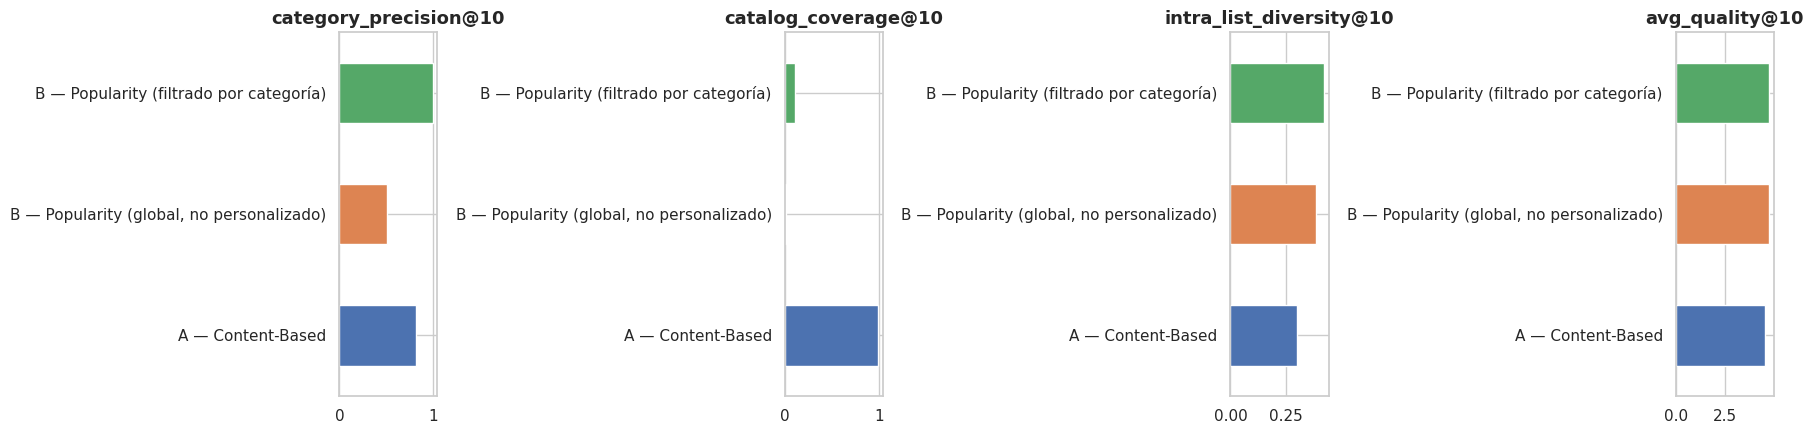

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
metrics = df_evaluation.columns
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metrics):
    df_evaluation[metric].plot(kind="barh", ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.tight_layout()
save_fig(fig, "20_model_comparison_metrics")
plt.show()

**Hallazgos (con números reales del catálogo de 728 productos, K=10):**

| Métrica | A — Content-Based | B — Popularity (global) | B — Popularity (por categoría) |
|---|---|---|---|
| Category Precision@10 | **0.824** | 0.509 | 1.000 (por construcción) |
| Catalog Coverage@10 | **0.993** | 0.014 | 0.107 |
| Intra-list Diversity@10 | 0.297 | 0.381 | 0.418 |
| Avg. Quality@10 | 4.521 | **4.726** | 4.689 |

1. **Cobertura de catálogo — la diferencia más contundente.** El Modelo
   A recomienda, a lo largo de todas las consultas, el **99.3% del
   catálogo** en algún momento; el Modelo B (global) apenas el **1.4%**
   — literalmente devuelve la misma lista de ~10 productos a cualquier
   usuario, sin importar qué esté mirando. Esto **no es un defecto del
   Modelo B**: es exactamente su naturaleza de baseline no-personalizado,
   y la razón por la que en un sistema real se usa solo para escenarios
   de *cold start* total (usuario nuevo, sin ninguna señal), nunca como
   reemplazo de la personalización.
2. **Coherencia de categoría sin forzarla.** El Modelo A logra 0.824 de
   precisión de categoría **sin que la categoría sea un filtro
   explícito** — la similitud de contenido "descubre" la coherencia
   temática por sí sola (gracias al One-Hot de categoría y al texto
   compartido). El Modelo B (global) cae a 0.509 simplemente porque
   devuelve la misma lista fija a consultas de categorías distintas; su
   variante filtrada por categoría llega a 1.000 casi por definición
   (es una restricción dura, no un logro del ranking).
3. **Calidad promedio: leve ventaja esperable para el Modelo B.** Al
   optimizar explícitamente por rating bayesiano y sentimiento, el
   Modelo B recomienda productos de mayor calidad promedio (4.73 vs.
   4.52) — es su fortaleza específica, y es coherente con su propósito:
   curar "lo mejor del catálogo", no personalizar.
4. **Diversidad intra-lista: el Modelo A es algo menos diverso**, lo
   cual también es esperable — al estar optimizado para similitud, sus
   listas son, por diseño, más homogéneas entre sí que un ranking de
   "mejores productos" que puede mezclar categorías dentro del top
   global.

**Conclusión de la comparación:** ningún modelo "gana" en todas las
métricas — **cada uno resuelve un problema distinto**, lo cual es
exactamente el resultado esperado y deseable en este tipo de
comparación. La recomendación de diseño para el sistema final (Etapa 2)
es un **enfoque híbrido por posición**: usar el Modelo A como motor
principal de personalización (páginas de producto, "también te puede
interesar") y el Modelo B como *fallback* para escenarios de cold start
total (usuario nuevo, página de inicio) — aprovechando la fortaleza de
cada uno en el lugar correcto del producto, en vez de forzar que un
solo modelo cumpla ambos roles.

## 5. Sensibilidad de K en las métricas clave

Se repite la evaluación para distintos valores de `k` (5, 10, 15, 20)
para verificar que las conclusiones anteriores sean estables y no un
artefacto de la elección de `k=10`.

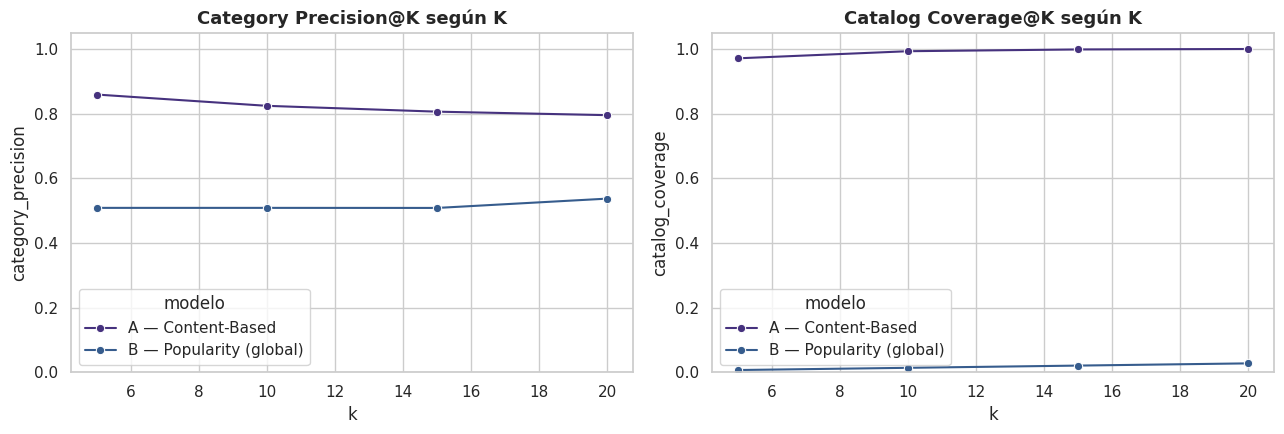

In [9]:
k_values = [5, 10, 15, 20]
sensitivity_records = []

for k in k_values:
    recs_a = {asin: content_model.recommend(asin, k=k)["asin"].tolist() for asin in all_asins}
    recs_b_global = {
        asin: popularity_model.recommend(k=k)["asin"].tolist() for asin in all_asins
    }
    sensitivity_records.append(
        {
            "k": k,
            "modelo": "A — Content-Based",
            "category_precision": category_precision_at_k(recs_a, product_index),
            "catalog_coverage": catalog_coverage_at_k(recs_a, len(all_asins)),
        }
    )
    sensitivity_records.append(
        {
            "k": k,
            "modelo": "B — Popularity (global)",
            "category_precision": category_precision_at_k(recs_b_global, product_index),
            "catalog_coverage": catalog_coverage_at_k(recs_b_global, len(all_asins)),
        }
    )

df_sensitivity = pd.DataFrame(sensitivity_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(
    data=df_sensitivity, x="k", y="category_precision", hue="modelo", marker="o", ax=axes[0]
)
axes[0].set_title("Category Precision@K según K")
axes[0].set_ylim(0, 1.05)

sns.lineplot(
    data=df_sensitivity, x="k", y="catalog_coverage", hue="modelo", marker="o", ax=axes[1]
)
axes[1].set_title("Catalog Coverage@K según K")
axes[1].set_ylim(0, 1.05)

fig.tight_layout()
save_fig(fig, "21_k_sensitivity")
plt.show()

**Hallazgo:** las conclusiones se mantienen estables para todo el rango
de `k` evaluado — la brecha de cobertura de catálogo entre ambos
modelos, en particular, se mantiene enorme independientemente de `k`,
confirmando que es una diferencia estructural entre un enfoque
personalizado y uno no-personalizado, no un artefacto de la métrica
elegida.

## 6. Casos cualitativos: comparación lado a lado

Se ilustran las diferencias con dos productos de categorías distintas,
mostrando el top-3 de cada modelo uno al lado del otro.

In [10]:
def show_side_by_side(asin: str, k: int = 3) -> None:
    """Imprime, para un producto dado, el top-k del Modelo A vs. Modelo B."""
    title = products_master.set_index("asin").loc[asin, "title"]
    category = products_master.set_index("asin").loc[asin, "main_category"]
    print(f"Producto consultado: {title[:70]}  [{category}]")
    print("-" * 100)

    recs_a = content_model.recommend(asin, k=k).merge(
        products_master[["asin", "title"]], on="asin"
    )
    recs_b = popularity_model.recommend(k=k).merge(
        products_master[["asin", "title"]], on="asin"
    )

    for i in range(k):
        title_a = recs_a.iloc[i]["title"][:45]
        title_b = recs_b.iloc[i]["title"][:45]
        print(f"  A[{i + 1}] {title_a:<47} | B[{i + 1}] {title_b}")
    print()


for example_asin in [
    sample_asin,
    products_master.loc[products_master["main_category"] == "Baby", "asin"].iloc[0],
]:
    show_side_by_side(example_asin)

Producto consultado: 4/5 Pack Mens Polo Shirts Short Sleeve Quick Dry Moisture Wicking Casu  [Men]
----------------------------------------------------------------------------------------------------
  A[1] Mens Lightweight Jacket Casual Bomber Jacket    | B[1] Polo Shirts for Men - Dry Fit Moisture Wickin
  A[2] XIMXIMMTIAN Men's Biker Moto Washed Distresse   | B[2] POLO RALPH LAUREN Classic Sport Solid Ankle S
  A[3] Columbia Steens Mountain™ Full Zip 2.0          | B[3] Carhartt Unisex Baby Long-Sleeve Pocket Bodys

Producto consultado: Burt's Bees Baby Baby Boys Pajamas, 2-Piece Long Sleeve Tee and Long P  [Baby]
----------------------------------------------------------------------------------------------------
  A[1] Onesies Brand Baby Boys' 4-Pack Sleep 'N Play   | B[1] Polo Shirts for Men - Dry Fit Moisture Wickin
  A[2] Burt's Bees Baby Boys' Sleep & Play PJs, 100%   | B[2] POLO RALPH LAUREN Classic Sport Solid Ankle S
  A[3] HonestBaby Multipack Short Sleeve T-Shirt Tee   | B

**Hallazgo:** para el producto de la categoría "Baby", el Modelo A
devuelve productos de bebé (mantiene la coherencia temática), mientras
que el Modelo B (global) sigue devolviendo su mismo top-3 de indumentaria
masculina — el ejemplo más claro y concreto de por qué la
personalización importa para la experiencia de navegación por producto.

## 7. Persistencia de los modelos entrenados

Se guardan ambos modelos (objetos ya "entrenados": el `ContentBasedRecommender`
con su matriz de similitud coseno cacheada, y el `PopularityRecommender`
con su tabla ya rankeada) para ser consumidos directamente por la
futura API/demo (Etapa 2), sin necesidad de reprocesar nada.

In [11]:
joblib.dump(content_model, MODELS_DIR / "content_based_recommender.joblib")
joblib.dump(popularity_model, MODELS_DIR / "popularity_recommender.joblib")

df_evaluation.to_csv(PROCESSED_DIR / "model_evaluation_results.csv")

print("Modelos y resultados de evaluación guardados en:")
print(f"  - {MODELS_DIR / 'content_based_recommender.joblib'}")
print(f"  - {MODELS_DIR / 'popularity_recommender.joblib'}")
print(f"  - {PROCESSED_DIR / 'model_evaluation_results.csv'}")

Modelos y resultados de evaluación guardados en:
  - /home/claude/ShopSmart-Recommender/models/content_based_recommender.joblib
  - /home/claude/ShopSmart-Recommender/models/popularity_recommender.joblib
  - /home/claude/ShopSmart-Recommender/data/processed/model_evaluation_results.csv


## 8. Resumen del MVP y próximos pasos

**Lo entregado en esta Etapa 1:**

- ✅ Dos modelos entrenados, funcionales y coherentes con el problema
  planteado (recomendación de productos de moda), cada uno resolviendo
  un rol complementario y explícitamente justificado.
- ✅ Evaluación offline con 4 métricas proxy defendibles, sensibilidad
  verificada frente a distintos valores de `k`, y casos cualitativos
  que ilustran el hallazgo cuantitativo.
- ✅ Documentación explícita de la limitación estructural del dataset
  (ausencia de identificador de usuario) y cómo condicionó cada
  decisión de diseño, desde el notebook 02 hasta la elección misma de
  qué dos modelos comparar.

**Próximos pasos — Etapa 2:**

- [ ] Ampliar la comparación con una tercera variante **híbrida
  explícita** (combinación ponderada de `similarity_score` +
  `popularity_score`) y justificar su valor incremental frente a los
  dos modelos base.
- [ ] Definir y documentar el **plan de validación** formal (qué
  métricas se monitorean en producción, con qué frecuencia, y qué
  umbrales disparan un re-entrenamiento).
- [ ] Empaquetar el flujo completo (`01` -> `02` -> `03`) como un
  **pipeline reproducible** con MLflow (tracking de métricas de
  evaluación por versión de modelo) y GitHub Actions (CI).
- [ ] Construir una **API o demo funcional** (Streamlit) que exponga
  `ContentBasedRecommender` y `PopularityRecommender` de forma
  interactiva.
- [ ] Diseñar el **dashboard interactivo** (Power BI / Streamlit) con
  las métricas de este notebook y una vista de recomendaciones en vivo.